<a href="https://colab.research.google.com/github/yejinPARK48/michigan_building_detection/blob/main/05_evaluation/washtenaw_generalization_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Out-of-Sample Generalization Test — Washtenaw County (Ann Arbor)

Washtenaw County was **not included** in the 19-county training set.
This notebook fetches NAIP imagery, generates tiles, runs the trained seg-only U-Net,
and evaluates results at block group level with tier distribution (Dense / Sparse / Empty).


## Technical Challenges — Washtenaw County Tile Generation

**CRS mismatch:** NAIP images are stored in UTM (meters) while tile bboxes are in WGS84 (lat/lon), causing incorrect window calculations and read failures. Fixed by transforming bbox to the image's native CRS before reading.

**SSL certificate error:** Planetary Computer API returned SSL verification failures in multi-threaded environment. Fixed by disabling SSL verification.

**fp_gdf not accessible in threads:** Microsoft Building Footprint GeoDataFrame was not accessible inside worker threads. Fixed by declaring it as a global variable within the thread function.

## 0. Setup

In [ ]:
# ── SSL patch MUST be first before any other imports ─────────────────────
import os, ssl, urllib3

os.environ['CURL_CA_BUNDLE']     = ''
os.environ['REQUESTS_CA_BUNDLE'] = ''
ssl._create_default_https_context = ssl._create_unverified_context
urllib3.disable_warnings()


In [ ]:
!pip install pystac-client planetary-computer rasterio geopandas shapely pyogrio -q
!pip install segmentation-models-pytorch albumentations opencv-python-headless scikit-image -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.7 MB/s eta 0:00:00


In [ ]:
import os, warnings, zipfile, urllib.request, time
import numpy as np
import pandas as pd
import geopandas as gpd
from PIL import Image
from shapely.geometry import box
from skimage import measure
import matplotlib.pyplot as plt

import rasterio
from rasterio.features import rasterize
from rasterio.windows import from_bounds
from rasterio.enums import Resampling
from rasterio.crs import CRS
from rasterio.warp import transform_bounds

import pystac_client
import planetary_computer as pc
pc.settings.set_subscription_key("0162e7782ab28b85cda3c77b61875ca3210a1c31")

import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from google.colab import drive
drive.mount('/content/drive')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')


Mounted at /content/drive
Device: cuda


## 0-2. Config

In [ ]:
BASE_DIR      = '/content/drive/MyDrive/michigan_unet_project'
CKPT_DIR      = f'{BASE_DIR}/checkpoints'
SEG_CKPT      = f'{CKPT_DIR}/unet_seg_best_full_curated.pt'

OUT_DIR       = f'{BASE_DIR}/results_washtenaw'
TILE_IMG_DIR  = '/content/washtenaw/images'
TILE_MASK_DIR = '/content/washtenaw/masks'

for d in [OUT_DIR, TILE_IMG_DIR, TILE_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

WASHTENAW_FIPS = '161'
TILE_SIZE_M    = 256
TILE_SIZE_PX   = 512
BEST_THRESHOLD = 0.5
BEST_MIN_AREA  = 50

DENSE_THRESHOLD  = 0.05
SPARSE_THRESHOLD = 0.001

def classify_tier(ratio):
    if ratio >= DENSE_THRESHOLD:    return 'Dense'
    elif ratio >= SPARSE_THRESHOLD: return 'Sparse'
    else:                           return 'Empty'

print(f'Checkpoint exists: {os.path.exists(SEG_CKPT)}')
print(f'Output dir: {OUT_DIR}')


Checkpoint exists: True
Output dir: /content/drive/MyDrive/michigan_unet_project/results_washtenaw


## 1. Load TIGER Shapefile + MS Footprints

In [ ]:
# ── TIGER Block Group Shapefile (already in Drive) ────────────────────────
SHP_PATH = f'{BASE_DIR}/tl_2020_26_bg.shp'

gdf_bg = gpd.read_file(SHP_PATH)
gdf_bg = gdf_bg[gdf_bg['COUNTYFP'] == WASHTENAW_FIPS].reset_index(drop=True)
gdf_bg = gdf_bg.to_crs(epsg=4326)
gdf_bg = gdf_bg.rename(columns={'GEOID': 'geoid'})
print(f'Washtenaw block groups: {len(gdf_bg)}')


Washtenaw block groups: 308


In [ ]:
# ── Microsoft Building Footprints (Michigan) ──────────────────────────────
MS_DIR  = '/content/ms_michigan/'
MS_PATH = f'{MS_DIR}/Michigan.geojson'
os.makedirs(MS_DIR, exist_ok=True)

if not os.path.exists(MS_PATH):
    url      = 'https://minedbuildings.z5.web.core.windows.net/legacy/usbuildings-v2/Michigan.geojson.zip'
    zip_path = '/content/Michigan.geojson.zip'
    print('Downloading Michigan footprints...')
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(MS_DIR)
    print('Done!')

washtenaw_bounds = gdf_bg.total_bounds
fp_gdf = gpd.read_file(MS_PATH, bbox=tuple(washtenaw_bounds)).to_crs(epsg=4326)
print(f'Footprints in Washtenaw: {len(fp_gdf):,}')


Done!
Footprints in Washtenaw: 131,613


## 2. Helper Functions

In [ ]:
import pyproj
from shapely.ops import transform as shp_transform

def split_bbox_into_tiles_m(row, tile_size_m=256, crs_utm=26917):
    proj_wgs = pyproj.CRS('EPSG:4326')
    proj_utm = pyproj.CRS(f'EPSG:{crs_utm}')
    to_utm   = pyproj.Transformer.from_crs(proj_wgs, proj_utm, always_xy=True).transform
    to_wgs   = pyproj.Transformer.from_crs(proj_utm, proj_wgs, always_xy=True).transform
    geom_utm = shp_transform(to_utm, row.geometry)
    minx, miny, maxx, maxy = geom_utm.bounds
    tiles = []
    x = minx
    while x < maxx:
        y = miny
        while y < maxy:
            tile_utm = box(x, y, x + tile_size_m, y + tile_size_m)
            if tile_utm.intersects(geom_utm):
                tile_wgs = shp_transform(to_wgs, tile_utm)
                tiles.append(tile_wgs.bounds)
            y += tile_size_m
        x += tile_size_m
    return tiles


def fetch_naip_tile(bbox, year=2020, size_px=512, max_retries=3):
    for attempt in range(max_retries):
        try:
            catalog = pystac_client.Client.open(
                'https://planetarycomputer.microsoft.com/api/stac/v1',
                modifier=pc.sign_inplace
            )
            items = catalog.search(
                collections=['naip'], bbox=bbox,
                datetime=f'{year}-01-01/{year}-12-31', max_items=5
            ).item_collection()
            if len(items) == 0: return None
            href = pc.sign(items[0].assets['image'].href)
            with rasterio.open(href) as src:
                # Convert bbox from WGS84 to image CRS
                bbox_transformed = transform_bounds(
                    CRS.from_epsg(4326), src.crs,
                    bbox[0], bbox[1], bbox[2], bbox[3]
                )
                window = from_bounds(*bbox_transformed, transform=src.transform)
                data   = src.read([1,2,3], window=window,
                                   out_shape=(3, size_px, size_px),
                                   resampling=Resampling.bilinear)
            return np.transpose(data, (1,2,0)).astype(np.uint8)
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2)
            else:
                return None
    return None


def get_footprint_mask(bbox, fp_gdf_local, size_px=512):
    minx, miny, maxx, maxy = bbox
    transform = rasterio.transform.from_bounds(minx, miny, maxx, maxy, size_px, size_px)
    clip = fp_gdf_local.cx[minx:maxx, miny:maxy]
    if len(clip) == 0:
        return np.zeros((size_px, size_px), dtype=np.uint8), 0
    shapes = [(geom, 1) for geom in clip.geometry]
    mask   = rasterize(shapes, out_shape=(size_px, size_px),
                       transform=transform, fill=0, dtype=np.uint8)
    return mask, len(clip)

print('Helper functions ready.')


Helper functions ready.


## 3. Generate Tiles

In [ ]:
import concurrent.futures
from threading import Lock

CHECKPOINT_CSV = f'{OUT_DIR}/washtenaw_tile_metadata.csv'

if os.path.exists(CHECKPOINT_CSV):
    try:
        df_existing = pd.read_csv(CHECKPOINT_CSV, dtype={'geoid': str})
        if df_existing.empty or len(df_existing.columns) == 0:
            raise ValueError("Empty file")
        tile_records = df_existing.to_dict('records')
        done_tids    = set(df_existing['tile_id'].tolist())
        print(f'Resuming — already saved: {len(tile_records)} tiles')
    except (pd.errors.EmptyDataError, ValueError):
        print('Checkpoint file is empty — starting fresh.')
        tile_records = []
        done_tids    = set()
else:
    tile_records = []
    done_tids    = set()

total_bboxes = sum(len(split_bbox_into_tiles_m(row)) for _, row in gdf_bg.iterrows())
print(f'Generating tiles for {len(gdf_bg)} block groups (~{total_bboxes} bboxes)...')

lock         = Lock()
saved_count  = [0]
failed_count = [0]

def process_bg(args):
    bg_idx, (row, fp_gdf_local) = args
    geoid  = row['geoid']
    bboxes = split_bbox_into_tiles_m(row)
    local_records = []

    for j, bbox in enumerate(bboxes):
        tid = f'washtenaw_{geoid}_{j:03d}'
        with lock:
            if tid in done_tids:
                continue

        img_np = fetch_naip_tile(bbox)
        if img_np is None:
            with lock:
                failed_count[0] += 1
            continue

        mask_np, fp_cnt = get_footprint_mask(bbox, fp_gdf_local)
        ratio = mask_np.sum() / (mask_np.shape[0] * mask_np.shape[1])
        tier  = classify_tier(ratio)

        Image.fromarray(img_np).save(f'{TILE_IMG_DIR}/{tid}.png')
        Image.fromarray(mask_np * 255).save(f'{TILE_MASK_DIR}/{tid}.png')

        local_records.append({
            'tile_id': tid, 'geoid': geoid,
            'county_fips': '26161', 'county_name': 'Washtenaw',
            'state_fips': '26', 'state_name': 'Michigan',
            'tract_fips': geoid[:11], 'bg_id': geoid[11:],
            'bbox_minx': bbox[0], 'bbox_miny': bbox[1],
            'bbox_maxx': bbox[2], 'bbox_maxy': bbox[3],
            'footprint_count': fp_cnt,
            'mask_building_ratio': round(float(ratio), 6),
            'tier': tier,
        })
        with lock:
            saved_count[0] += 1

    return bg_idx, local_records

# ── Parallel execution ────────────────────────────────────────────────────
WORKERS   = 4
args_list = list(enumerate((row, fp_gdf) for _, row in gdf_bg.iterrows()))

with concurrent.futures.ThreadPoolExecutor(max_workers=WORKERS) as executor:
    futures = {executor.submit(process_bg, a): a[0] for a in args_list}

    for i, future in enumerate(concurrent.futures.as_completed(futures)):
        bg_idx, local_records = future.result()
        with lock:
            tile_records.extend(local_records)
            done_tids.update(r['tile_id'] for r in local_records)

        if (i + 1) % 10 == 0:
            pd.DataFrame(tile_records).to_csv(CHECKPOINT_CSV, index=False)
            print(f'[{i+1}/{len(gdf_bg)}] saved={saved_count[0]} failed={failed_count[0]}')

df_tiles = pd.DataFrame(tile_records)
df_tiles.to_csv(CHECKPOINT_CSV, index=False)
print(f'\nDone! Total tiles: {len(df_tiles)} | Failed: {failed_count[0]}')
print('\n[Tier Distribution]')
print(df_tiles['tier'].value_counts().to_string())
print(f'\nMean footprint count: {df_tiles.footprint_count.mean():.2f}')


Resuming — already saved: 12282 tiles
Generating tiles for 308 block groups (~32703 bboxes)...


[10/308] saved=117 failed=0
[20/308] saved=121 failed=0
[30/308] saved=123 failed=0
[40/308] saved=125 failed=0
[50/308] saved=129 failed=0
[60/308] saved=132 failed=0
[70/308] saved=136 failed=0
[80/308] saved=137 failed=0
[90/308] saved=141 failed=0
[100/308] saved=142 failed=0
[110/308] saved=165 failed=0
[120/308] saved=168 failed=0
[130/308] saved=169 failed=0
[140/308] saved=172 failed=0
[150/308] saved=176 failed=0
[160/308] saved=181 failed=0
[170/308] saved=184 failed=0


[180/308] saved=1679 failed=0


[190/308] saved=3587 failed=0


[200/308] saved=5338 failed=0


...

[270/308] saved=16711 failed=0


[280/308] saved=28043 failed=0


[290/308] saved=34271 failed=0


[300/308] saved=37143 failed=0



Done! Total tiles: 32703 | Failed: 0

[Tier Distribution]
tier
Empty     14395
Sparse    14286
Dense      4022

Mean footprint count: 6.21


## 4. Model Inference

In [ ]:
model = smp.Unet(encoder_name='resnet34', encoder_weights=None,
                 in_channels=3, classes=1, activation=None).to(DEVICE)
model.load_state_dict(torch.load(SEG_CKPT, map_location=DEVICE))
model.eval()
print('Model loaded.')

val_aug = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class InferenceDataset(Dataset):
    def __init__(self, tile_ids, img_dir, transform=None):
        self.tile_ids  = tile_ids
        self.img_dir   = img_dir
        self.transform = transform
    def __len__(self): return len(self.tile_ids)
    def __getitem__(self, idx):
        tid = self.tile_ids[idx]
        img = np.array(Image.open(f'{self.img_dir}/{tid}.png').convert('RGB'))
        if self.transform:
            img = self.transform(image=img)['image']
        return img, tid

inf_ds = InferenceDataset(df_tiles['tile_id'].tolist(), TILE_IMG_DIR, val_aug)
inf_ld = DataLoader(inf_ds, batch_size=8, shuffle=False, num_workers=2)

gt_map = dict(zip(df_tiles['tile_id'], df_tiles['footprint_count']))

results = []
with torch.no_grad():
    for imgs, tids in inf_ld:
        seg_logits = model(imgs.to(DEVICE))
        pred_masks = (torch.sigmoid(seg_logits) > BEST_THRESHOLD).cpu().numpy()
        for b in range(len(tids)):
            tid     = tids[b]
            labeled = measure.label(pred_masks[b, 0])
            cc_cnt  = sum(1 for r in measure.regionprops(labeled) if r.area >= BEST_MIN_AREA)
            results.append({'tile_id': tid, 'cc_count': cc_cnt,
                            'gt_count': gt_map.get(tid, 0)})

df_results = pd.DataFrame(results)
df_results = df_results.merge(
    df_tiles[['tile_id','geoid','county_fips','county_name',
              'mask_building_ratio','tier','bbox_minx','bbox_miny','bbox_maxx','bbox_maxy']],
    on='tile_id')
df_results.to_csv(f'{OUT_DIR}/washtenaw_predictions.csv', index=False)

mae  = np.abs(df_results['cc_count'] - df_results['gt_count']).mean()
corr = np.corrcoef(df_results['cc_count'], df_results['gt_count'])[0,1]
print(f'Inference complete: {len(df_results)} tiles')
print(f'Overall MAE: {mae:.2f} | Pearson r: {corr:.4f}')


Model loaded.
Inference complete: 32703 tiles
Overall MAE: 1.42 | Pearson r: 0.9543


## 5. Block Group Aggregation + Tier-Stratified Evaluation

In [ ]:
bg_results = df_results.groupby('geoid').agg(
    pred_cc_count = ('cc_count',  'sum'),
    gt_fp_count   = ('gt_count',  'sum'),
    n_tiles       = ('tile_id',   'count'),
    mean_ratio    = ('mask_building_ratio', 'mean'),
).reset_index()

bg_results['bg_tier'] = bg_results['mean_ratio'].apply(classify_tier)

mae_bg  = np.abs(bg_results['pred_cc_count'] - bg_results['gt_fp_count']).mean()
corr_bg = np.corrcoef(bg_results['pred_cc_count'], bg_results['gt_fp_count'])[0,1]

print(f'Block groups: {len(bg_results)}')
print(f'Block group MAE: {mae_bg:.2f} | Pearson r: {corr_bg:.4f}')
print()
print('[Block Group Tier Distribution]')
print(bg_results['bg_tier'].value_counts().to_string())

bg_results.to_csv(f'{OUT_DIR}/washtenaw_bg_predictions.csv', index=False)

print('\n[Tier-Stratified Evaluation — Tile Level]')
print(f'{"Tier":<8} | {"N":>5} | {"MAE":>8} | {"Pearson r":>10}')
print('-' * 40)
for tier in ['Dense', 'Sparse', 'Empty']:
    sub = df_results[df_results['tier'] == tier]
    if len(sub) == 0: continue
    mae_t  = np.abs(sub['cc_count'] - sub['gt_count']).mean()
    corr_t = np.corrcoef(sub['cc_count'], sub['gt_count'])[0,1] if sub['cc_count'].std() > 0 else 0.0
    print(f'{tier:<8} | {len(sub):>5} | {mae_t:>8.2f} | {corr_t:>10.4f}')


Block groups: 308
Block group MAE: 90.13 | Pearson r: 0.9636

[Block Group Tier Distribution]
bg_tier
Dense     195
Sparse    113

[Tier-Stratified Evaluation — Tile Level]
Tier     |     N |      MAE |  Pearson r
----------------------------------------
Dense    |  4022 |     6.26 |     0.9155
Sparse   | 14286 |     1.33 |     0.8419
Empty    | 14395 |     0.16 |     0.1896


## 6. Visualization

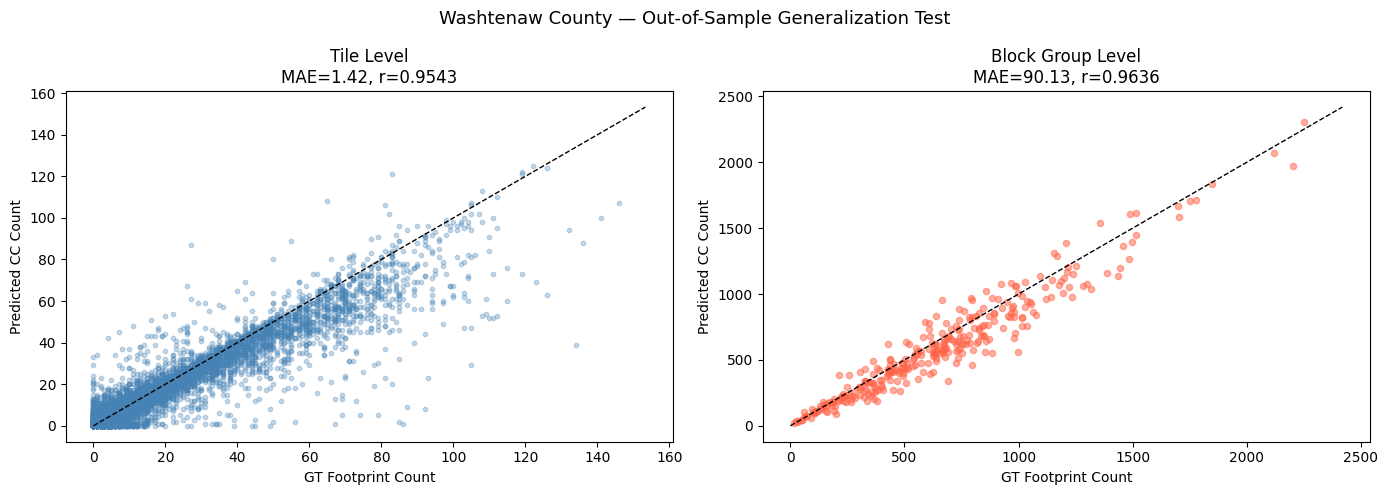

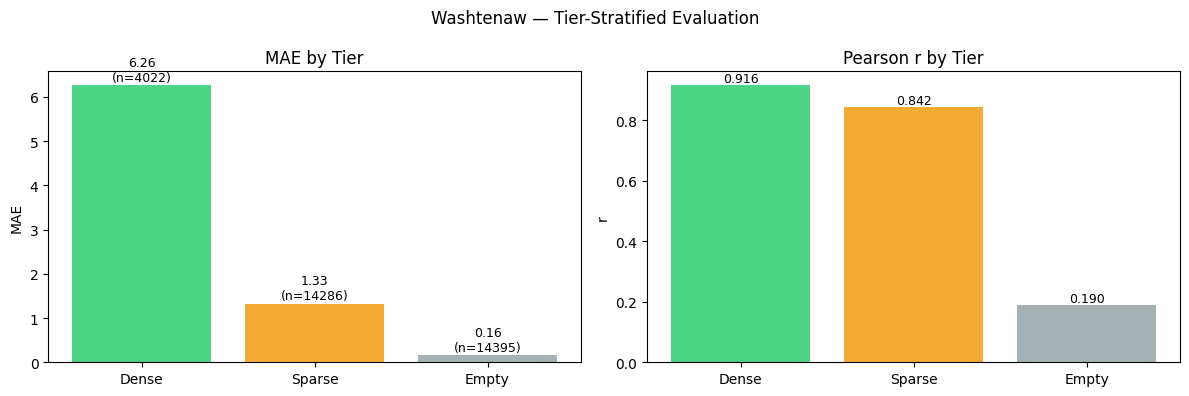

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_results['gt_count'], df_results['cc_count'],
                alpha=0.3, s=10, color='steelblue')
lim = max(df_results['gt_count'].max(), df_results['cc_count'].max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1)
axes[0].set_xlabel('GT Footprint Count')
axes[0].set_ylabel('Predicted CC Count')
axes[0].set_title(f'Tile Level\nMAE={mae:.2f}, r={corr:.4f}')

axes[1].scatter(bg_results['gt_fp_count'], bg_results['pred_cc_count'],
                alpha=0.5, s=20, color='tomato')
lim2 = max(bg_results['gt_fp_count'].max(), bg_results['pred_cc_count'].max()) * 1.05
axes[1].plot([0, lim2], [0, lim2], 'k--', linewidth=1)
axes[1].set_xlabel('GT Footprint Count')
axes[1].set_ylabel('Predicted CC Count')
axes[1].set_title(f'Block Group Level\nMAE={mae_bg:.2f}, r={corr_bg:.4f}')

plt.suptitle('Washtenaw County — Out-of-Sample Generalization Test', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/washtenaw_scatter.png', dpi=150)
plt.show()

tiers  = ['Dense', 'Sparse', 'Empty']
colors = ['#2ecc71', '#f39c12', '#95a5a6']
maes   = [np.abs(df_results[df_results['tier']==t]['cc_count'] -
                 df_results[df_results['tier']==t]['gt_count']).mean() for t in tiers]
corrs  = [np.corrcoef(df_results[df_results['tier']==t]['cc_count'],
                      df_results[df_results['tier']==t]['gt_count'])[0,1]
          if df_results[df_results['tier']==t]['cc_count'].std() > 0 else 0 for t in tiers]
ns     = [len(df_results[df_results['tier']==t]) for t in tiers]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(tiers, maes, color=colors, alpha=0.85)
axes[0].set_title('MAE by Tier'); axes[0].set_ylabel('MAE')
for i, (v, n) in enumerate(zip(maes, ns)):
    axes[0].text(i, v + 0.1, f'{v:.2f}\n(n={n})', ha='center', fontsize=9)

axes[1].bar(tiers, corrs, color=colors, alpha=0.85)
axes[1].set_title('Pearson r by Tier'); axes[1].set_ylabel('r')
for i, v in enumerate(corrs):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Washtenaw — Tier-Stratified Evaluation', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/washtenaw_tier_eval.png', dpi=150)
plt.show()


For Empty tiles, the low Pearson r (0.19) does not indicate poor performance — it reflects the lack of variance in both predicted and ground truth counts, which are near zero by definition. The MAE (Mean Absolute Error) of 0.16, meaning predictions differ from ground truth by less than 0.2 buildings per tile on average, confirms that the model is accurately identifying the absence of buildings in these tiles.

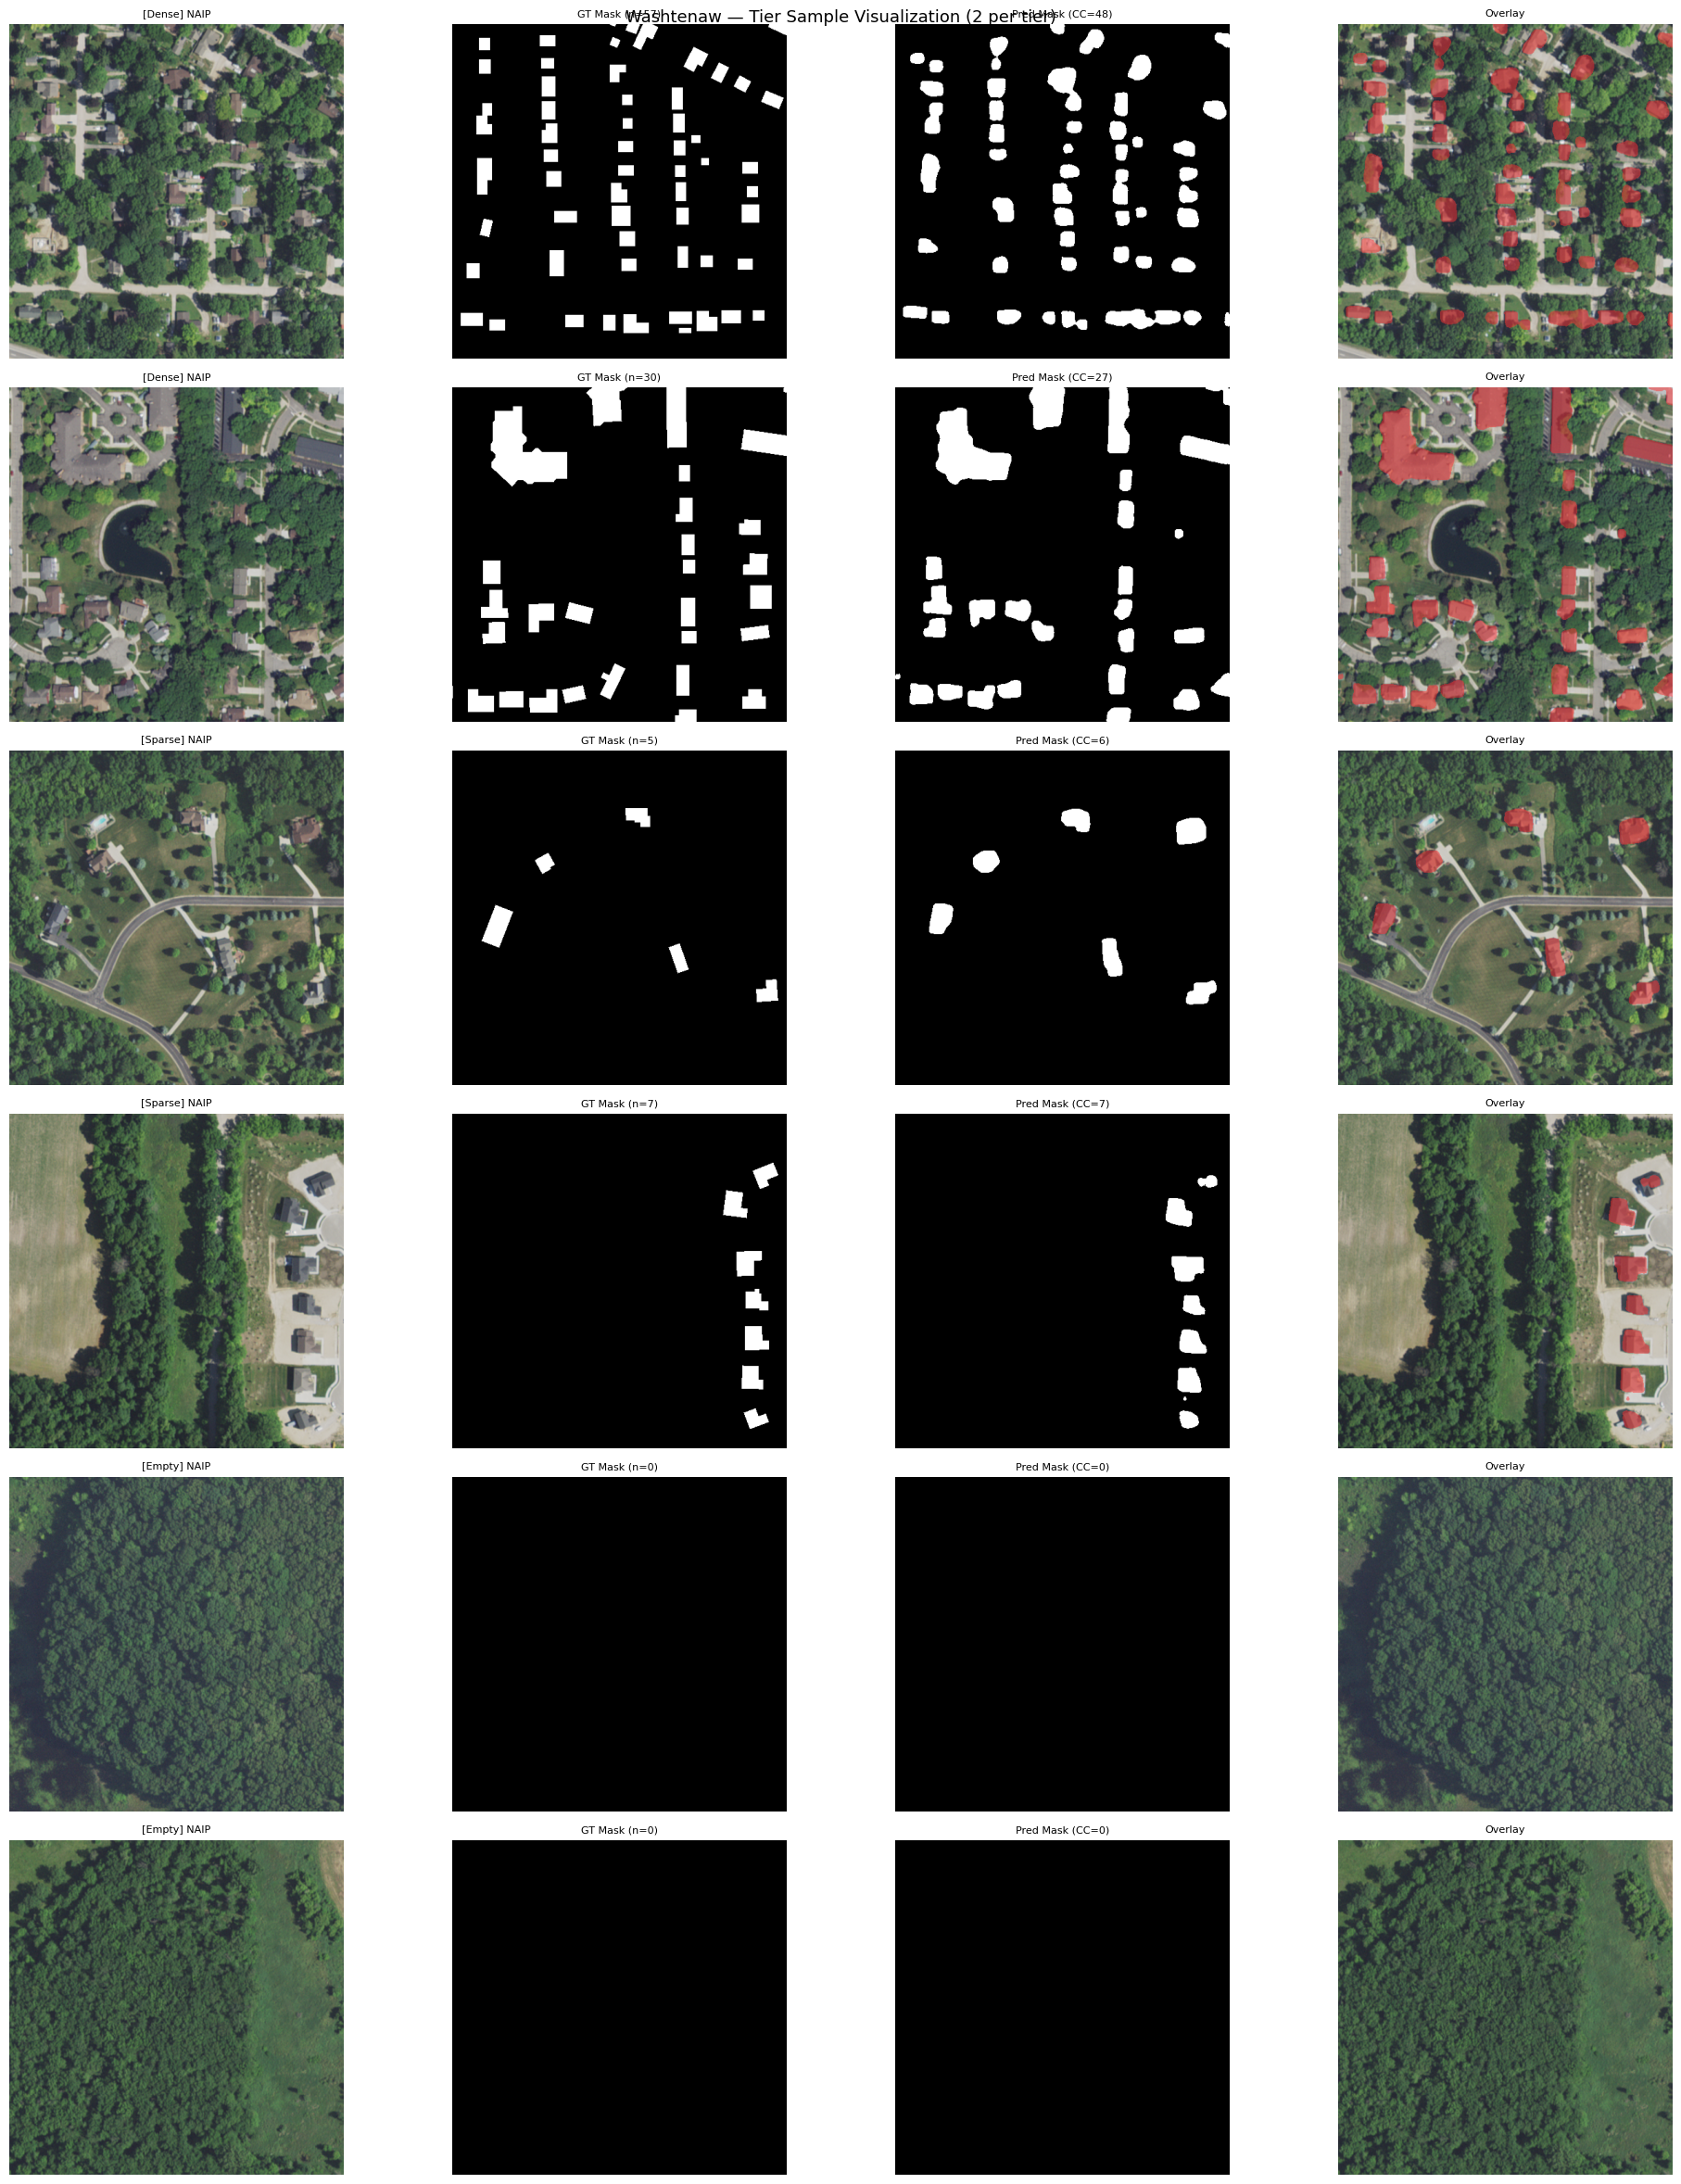

In [ ]:
# ── Visualize 2 samples per tier ──────────────────────────────────────────
fig, axes = plt.subplots(6, 4, figsize=(20, 4 * 6))

model.eval()
row_idx = 0

for tier in ['Dense', 'Sparse', 'Empty']:
    tier_tiles = df_results[df_results['tier'] == tier]
    samples    = tier_tiles.sample(min(2, len(tier_tiles)), random_state=42)

    for _, tile_row in samples.iterrows():
        tid    = tile_row['tile_id']
        cc_cnt = int(tile_row['cc_count'])
        gt_cnt = int(tile_row['gt_count'])

        img_np   = np.array(Image.open(f'{TILE_IMG_DIR}/{tid}.png').convert('RGB'))
        mask_np  = np.array(Image.open(f'{TILE_MASK_DIR}/{tid}.png').convert('L'))

        aug   = val_aug(image=img_np)
        img_t = aug['image'].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            seg_logit = model(img_t)
        pred_mask = (torch.sigmoid(seg_logit[0, 0]) > BEST_THRESHOLD).cpu().numpy()

        overlay = img_np.copy()
        overlay[pred_mask] = (overlay[pred_mask] * 0.5 + np.array([255, 50, 50]) * 0.5).astype(np.uint8)

        axes[row_idx][0].imshow(img_np)
        axes[row_idx][0].set_title(f'[{tier}] NAIP', fontsize=8)
        axes[row_idx][1].imshow(mask_np > 127, cmap='gray')
        axes[row_idx][1].set_title(f'GT Mask (n={gt_cnt})', fontsize=8)
        axes[row_idx][2].imshow(pred_mask, cmap='gray')
        axes[row_idx][2].set_title(f'Pred Mask (CC={cc_cnt})', fontsize=8)
        axes[row_idx][3].imshow(overlay)
        axes[row_idx][3].set_title('Overlay', fontsize=8)

        for ax in axes[row_idx]: ax.axis('off')
        row_idx += 1

plt.suptitle('Washtenaw — Tier Sample Visualization (2 per tier)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/washtenaw_tier_samples.png', dpi=120, bbox_inches='tight')
plt.show()

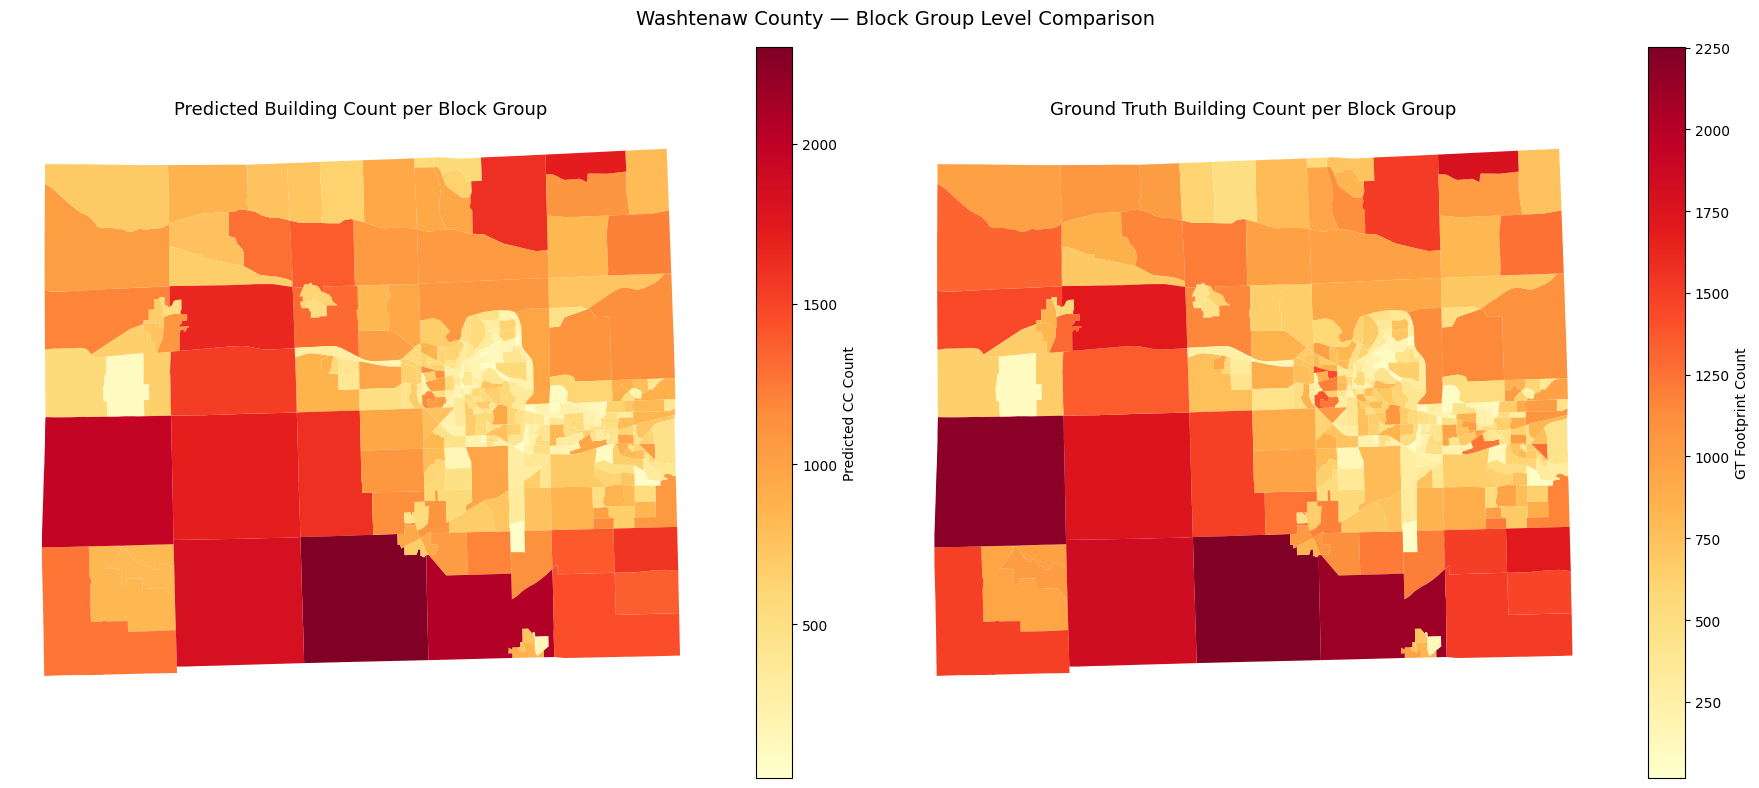

In [ ]:
# ── Block Group Level Visualization ──────────────────────────────────────
import geopandas as gpd
import subprocess

shp_path = f'{BASE_DIR}/tl_2020_26_bg.shp'
if not os.path.exists(shp_path):
    print("Downloading shapefile...")
    subprocess.run(['wget', '-q',
        'https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_26_bg.zip',
        '-O', f'{BASE_DIR}/tl_2020_26_bg.zip'])
    subprocess.run(['unzip', '-q', f'{BASE_DIR}/tl_2020_26_bg.zip',
                    '-d', f'{BASE_DIR}/'])
    print("Done!")

gdf_bg = gpd.read_file(shp_path)
gdf_bg = gdf_bg[gdf_bg['COUNTYFP'] == '161'].rename(columns={'GEOID': 'geoid'})[['geoid', 'geometry']]
gdf_bg = gdf_bg.to_crs(epsg=4326)

gdf_merged = gdf_bg.merge(bg_results[['geoid', 'pred_cc_count', 'gt_fp_count', 'bg_tier']],
                           on='geoid', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

gdf_merged.plot(column='pred_cc_count', ax=axes[0],
                cmap='YlOrRd', legend=True,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={'label': 'Predicted CC Count'})
axes[0].set_title('Predicted Building Count per Block Group', fontsize=13)
axes[0].axis('off')

gdf_merged.plot(column='gt_fp_count', ax=axes[1],
                cmap='YlOrRd', legend=True,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={'label': 'GT Footprint Count'})
axes[1].set_title('Ground Truth Building Count per Block Group', fontsize=13)
axes[1].axis('off')

plt.suptitle('Washtenaw County — Block Group Level Comparison', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/washtenaw_bg_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Block Group Level Interactive Map with Predicted Masks ────────────────
import folium
import branca.colormap as cm
import base64
from io import BytesIO

gdf_map = gdf_bg.merge(bg_results[['geoid', 'pred_cc_count', 'gt_fp_count']],
                        on='geoid', how='left').to_crs(epsg=4326)

washtenaw_extent = gdf_map.total_bounds
washtenaw_bounds = [[washtenaw_extent[1], washtenaw_extent[0]],
                    [washtenaw_extent[3], washtenaw_extent[2]]]

m = folium.Map(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery'
)
m.fit_bounds(washtenaw_bounds)

# ── Block group boundaries ────────────────────────────────────────────────
vmax = gdf_map['pred_cc_count'].quantile(0.95)
colormap_pred = cm.LinearColormap(['#ffffb2','#fd8d3c','#bd0026'],
                                   vmin=0, vmax=vmax,
                                   caption='Predicted Building Count')

folium.GeoJson(
    gdf_map.__geo_interface__,
    name='Block Groups',
    style_function=lambda f: {
        'fillColor'  : colormap_pred(f['properties']['pred_cc_count'] or 0),
        'color'      : 'white',
        'weight'     : 0.8,
        'fillOpacity': 0.3,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['geoid', 'pred_cc_count', 'gt_fp_count'],
        aliases=['GEOID', 'Predicted CC', 'GT Footprints'],
    )
).add_to(m)

# ── Predicted mask overlays (blue) ────────────────────────────────────────
model.eval()
mask_layer = folium.FeatureGroup(name='Predicted Masks', show=True)

for _, row in df_results[df_results['cc_count'] > 0].iterrows():
    tid = row['tile_id']

    img_np  = np.array(Image.open(f'{TILE_IMG_DIR}/{tid}.png').convert('RGB'))
    aug     = val_aug(image=img_np)
    img_t   = aug['image'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        seg_logit = model(img_t)
    pred_mask = (torch.sigmoid(seg_logit[0, 0]) > BEST_THRESHOLD).cpu().numpy()

    if pred_mask.sum() == 0:
        continue

    overlay = np.zeros((*pred_mask.shape, 4), dtype=np.uint8)
    overlay[pred_mask] = [50, 100, 255, 180]

    buf = BytesIO()
    Image.fromarray(overlay, 'RGBA').save(buf, format='PNG')
    b64 = base64.b64encode(buf.getvalue()).decode()

    tile_bounds = [[row['bbox_miny'], row['bbox_minx']],
                   [row['bbox_maxy'], row['bbox_maxx']]]

    folium.raster_layers.ImageOverlay(
        image=f'data:image/png;base64,{b64}',
        bounds=tile_bounds,
        opacity=0.7,
    ).add_to(mask_layer)

mask_layer.add_to(m)
colormap_pred.add_to(m)
folium.LayerControl().add_to(m)

map_path = f'{OUT_DIR}/washtenaw_bg_mask_map.html'
m.save(map_path)
print(f'Saved: {map_path}')

from IPython.display import display
display(m)